# Report visualisations -- SNOW hazard & risk, Kazakhstan

In [1]:
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [2]:
# Configuration -- must match snow_hazard_kazakhstan.py and snow_risk_kazakhstan.py
region_id       = 'KAZ'
hist_start_year = 1991
hist_end_year   = 1995
fut_start_year  = 2046
fut_end_year    = 2050
gcm_model       = 'GFDL-ESM4'
ssp_primary     = 'ssp126'
ssp_secondary   = 'ssp370'   # loaded only if files are cached

work_dir = Path('SNOW_hazard')
data_dir = work_dir / f'data_{region_id}'
plot_dir = work_dir / f'plots_{region_id}' / 'report'
plot_dir.mkdir(parents=True, exist_ok=True)

shp_path = Path(r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp')  # <-- update to your local shapefile path

lat_north, lat_south = 57.0, 39.0
lon_west,  lon_east  = 45.0, 88.0
KZ_EXTENT = [lon_west - 1, lon_east + 1, lat_south - 1, lat_north + 1]
HL = f'{hist_start_year}-{hist_end_year}'
FL = f'{fut_start_year}-{fut_end_year}'

In [3]:
# Load ERA5 hazard outputs
era5_blizzard = xr.open_dataset(
    data_dir / f'BdayCount_AnaProb_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')
era5_snow6    = xr.open_dataset(
    data_dir / f'Snow6Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')
era5_snow25   = xr.open_dataset(
    data_dir / f'Snow25Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')

# Load ISIMIP3b historical
hist_blizzard = xr.open_dataarray(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
hist_snow6    = xr.open_dataarray(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
hist_snow25   = xr.open_dataarray(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')

# Load ISIMIP3b primary SSP
fut_blizzard = xr.open_dataarray(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_{ssp_primary}_{fut_start_year}_{fut_end_year}.nc')
fut_snow6    = xr.open_dataarray(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_{ssp_primary}_{fut_start_year}_{fut_end_year}.nc')
fut_snow25   = xr.open_dataarray(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_{ssp_primary}_{fut_start_year}_{fut_end_year}.nc')

# Load ISIMIP3b secondary SSP (optional)
_b2 = data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_{ssp_secondary}_{fut_start_year}_{fut_end_year}.nc'
if _b2.exists():
    ssp2_blizzard = xr.open_dataarray(_b2)
    ssp2_snow6    = xr.open_dataarray(
        data_dir / f'Snow6Prob_annual_mean_{gcm_model}_{ssp_secondary}_{fut_start_year}_{fut_end_year}.nc')
    ssp2_snow25   = xr.open_dataarray(
        data_dir / f'Snow25Prob_annual_mean_{gcm_model}_{ssp_secondary}_{fut_start_year}_{fut_end_year}.nc')
    print(f'Secondary scenario {ssp_secondary} loaded.')
else:
    ssp2_blizzard = ssp2_snow6 = ssp2_snow25 = None
    print(f'No {ssp_secondary} cache found -- Figure 5 will be skipped.')

# Load population grids
pop_era5   = xr.open_dataarray(data_dir / f'population_ERA5grid_{region_id}.nc')
pop_isimip = xr.open_dataarray(data_dir / f'population_ISIMIPgrid_{region_id}.nc')

print('All cached outputs loaded.')

Secondary scenario ssp370 loaded.
All cached outputs loaded.


In [4]:
# Change signals
def change_signal(fut, hist):
    return (fut - hist).where(hist > 1, other=0.0)

chg_blizzard = change_signal(fut_blizzard, hist_blizzard)
chg_snow6    = change_signal(fut_snow6,    hist_snow6)
chg_snow25   = change_signal(fut_snow25,   hist_snow25)

if ssp2_blizzard is not None:
    chg2_blizzard = change_signal(ssp2_blizzard, hist_blizzard)
    chg2_snow6    = change_signal(ssp2_snow6,    hist_snow6)
    chg2_snow25   = change_signal(ssp2_snow25,   hist_snow25)

print('Change signals computed.')

Change signals computed.


In [5]:
# Shapefile
kz_gdf = gpd.read_file(shp_path)
if kz_gdf.crs is None or kz_gdf.crs.to_epsg() != 4326:
    kz_gdf = kz_gdf.to_crs(epsg=4326)
kz_national = kz_gdf.dissolve()

In [6]:
# Plot utilities
def _kz_map(ax, kz_national):
    ax.set_extent(KZ_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN,   facecolor='aliceblue', edgecolor='black', linewidth=0.3)
    ax.add_feature(cfeature.LAND,    facecolor='#f0f0f0',   edgecolor='black', linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, linestyle=':',          linewidth=0.4)
    kz_national.boundary.plot(ax=ax, color='#222222', linewidth=0.9,
                              transform=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False


def _pcm(ax, da, levels, cmap, lat='latitude', lon='longitude'):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        p = da.plot.pcolormesh(ax=ax, x=lon, y=lat,
                               levels=levels, cmap=cmap,
                               transform=ccrs.PlateCarree(),
                               add_colorbar=False)
    return p


def _cbar(fig, p, ax, label='Annual probability (%)'):
    return fig.colorbar(p, ax=ax, shrink=0.55, pad=0.02, label=label)


def save_fig(fig, name):
    path = plot_dir / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

## Figure 1 -- ERA5 baseline: mean annual probability of snow hazards

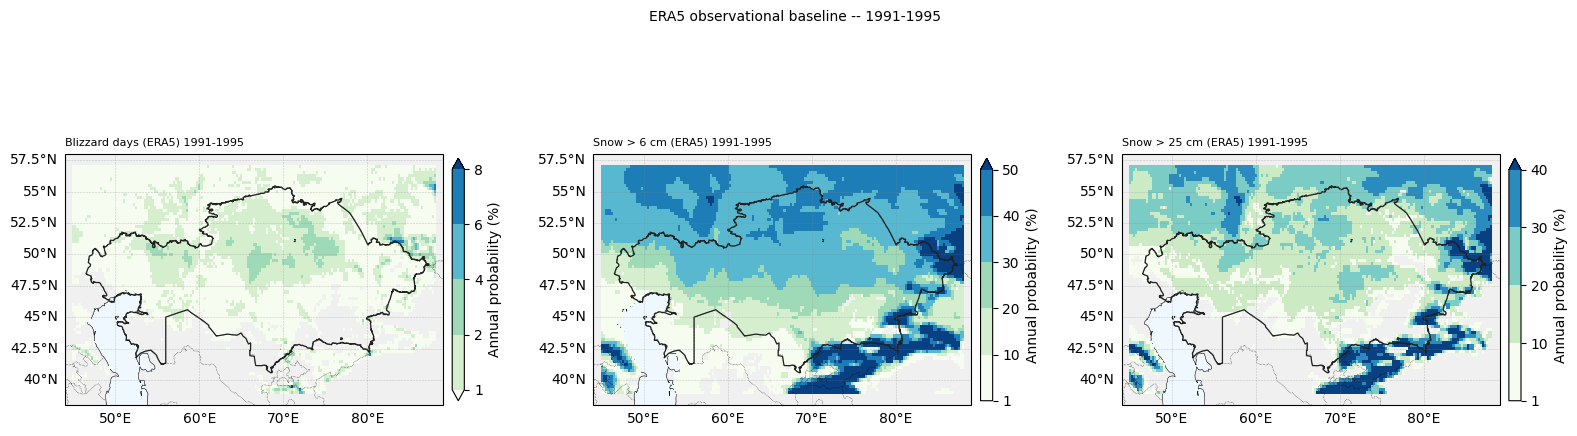

Saved: fig01_era5_baseline_hazard.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (da, lvl, title) in zip(axes, [
    (era5_blizzard.blizzard_days,
     [1, 2, 4, 6, 8],
     f'Blizzard days (ERA5) {HL}'),
    (era5_snow6.snow_days.where(era5_snow6.snow_days >= 1),
     [1, 10, 20, 30, 40, 50],
     f'Snow > 6 cm (ERA5) {HL}'),
    (era5_snow25.snow_days.where(era5_snow25.snow_days >= 1),
     [1, 10, 20, 30, 40],
     f'Snow > 25 cm (ERA5) {HL}'),
]):
    p = _pcm(ax, da, lvl, 'GnBu')
    _kz_map(ax, kz_national)
    ax.set_title(title, fontsize=8, loc='left')
    _cbar(fig, p, ax)

fig.suptitle(f'ERA5 observational baseline -- {HL}', fontsize=10, y=1.01)
plt.tight_layout()
save_fig(fig, 'fig01_era5_baseline_hazard.png')

## Figure 2 -- ISIMIP3b historical: mean annual probability of snow hazards

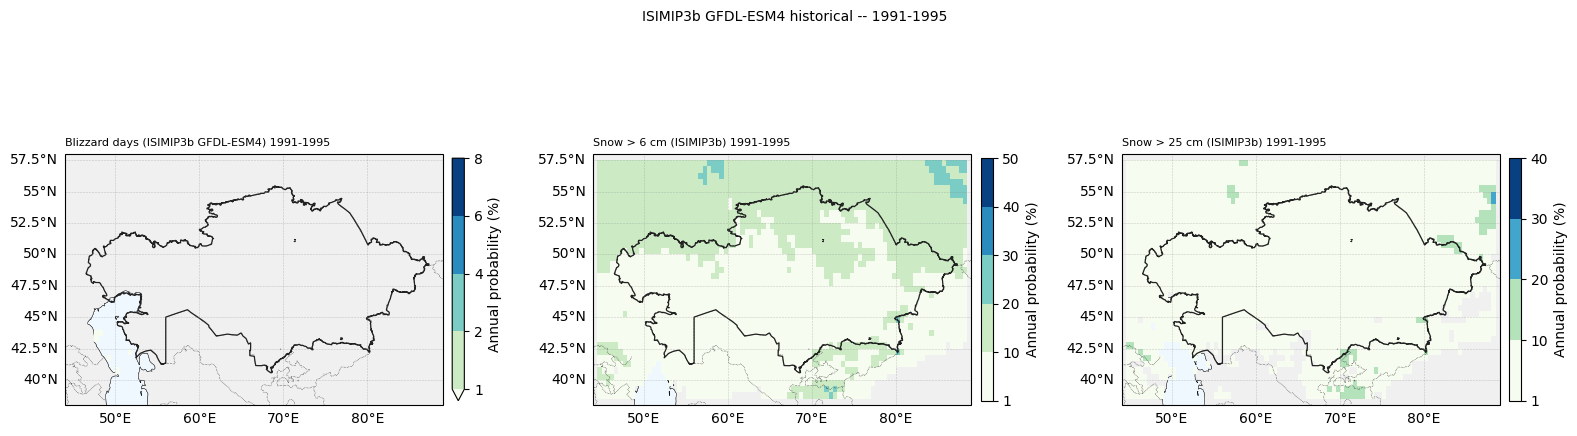

Saved: fig02_isimip3b_hist_hazard.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (da, lvl, title) in zip(axes, [
    (hist_blizzard,
     [1, 2, 4, 6, 8],
     f'Blizzard days (ISIMIP3b {gcm_model}) {HL}'),
    (hist_snow6.where(hist_snow6 >= 1),
     [1, 10, 20, 30, 40, 50],
     f'Snow > 6 cm (ISIMIP3b) {HL}'),
    (hist_snow25.where(hist_snow25 >= 1),
     [1, 10, 20, 30, 40],
     f'Snow > 25 cm (ISIMIP3b) {HL}'),
]):
    p = _pcm(ax, da, lvl, 'GnBu', lat='lat', lon='lon')
    _kz_map(ax, kz_national)
    ax.set_title(title, fontsize=8, loc='left')
    _cbar(fig, p, ax)

fig.suptitle(f'ISIMIP3b {gcm_model} historical -- {HL}', fontsize=10, y=1.01)
plt.tight_layout()
save_fig(fig, 'fig02_isimip3b_hist_hazard.png')

## Figure 3 -- Zonal mean annual probability: ERA5 vs ISIMIP3b

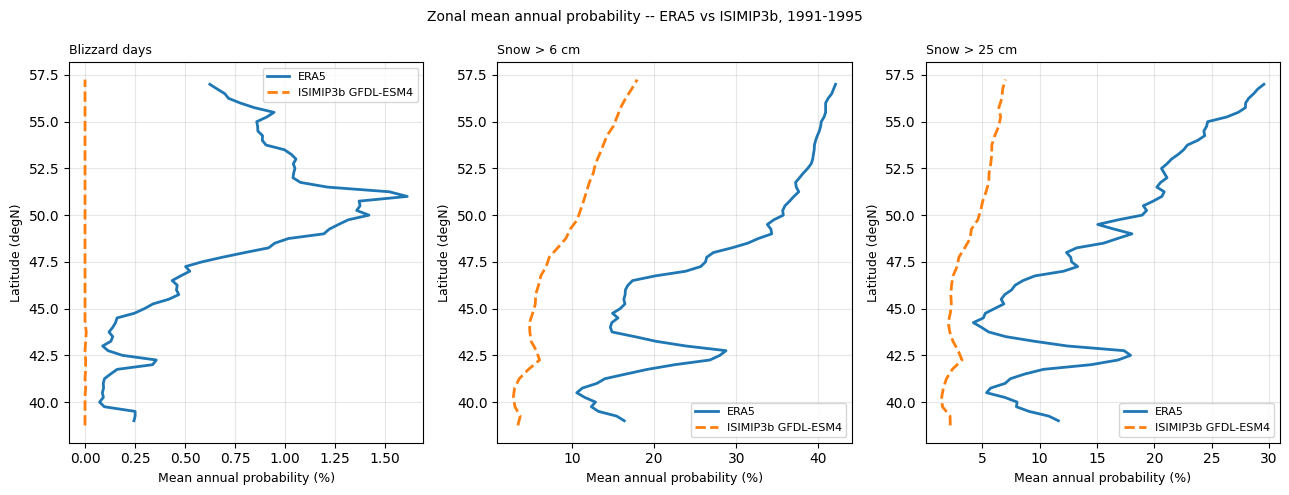

Saved: fig03_zonal_mean_profiles.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (e5_da, is_da, label) in zip(axes, [
    (era5_blizzard.blizzard_days, hist_blizzard, 'Blizzard days'),
    (era5_snow6.snow_days,        hist_snow6,    'Snow > 6 cm'),
    (era5_snow25.snow_days,       hist_snow25,   'Snow > 25 cm'),
]):
    e5z = e5_da.fillna(0).mean(dim='longitude')
    isz = is_da.fillna(0).mean(dim='lon')
    ax.plot(e5z.values, e5z.latitude.values,
            label='ERA5', color='#1f77b4', linewidth=2.0)
    ax.plot(isz.values, isz.lat.values,
            label=f'ISIMIP3b {gcm_model}', color='#ff7f0e',
            linewidth=2.0, linestyle='--')
    ax.set_xlabel('Mean annual probability (%)', fontsize=9)
    ax.set_ylabel('Latitude (degN)', fontsize=9)
    ax.set_title(label, fontsize=9, loc='left')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Zonal mean annual probability -- ERA5 vs ISIMIP3b, {HL}', fontsize=10)
plt.tight_layout()
save_fig(fig, 'fig03_zonal_mean_profiles.png')

## Figure 4 -- Projected change in snow hazard probability (SSP1-2.6)

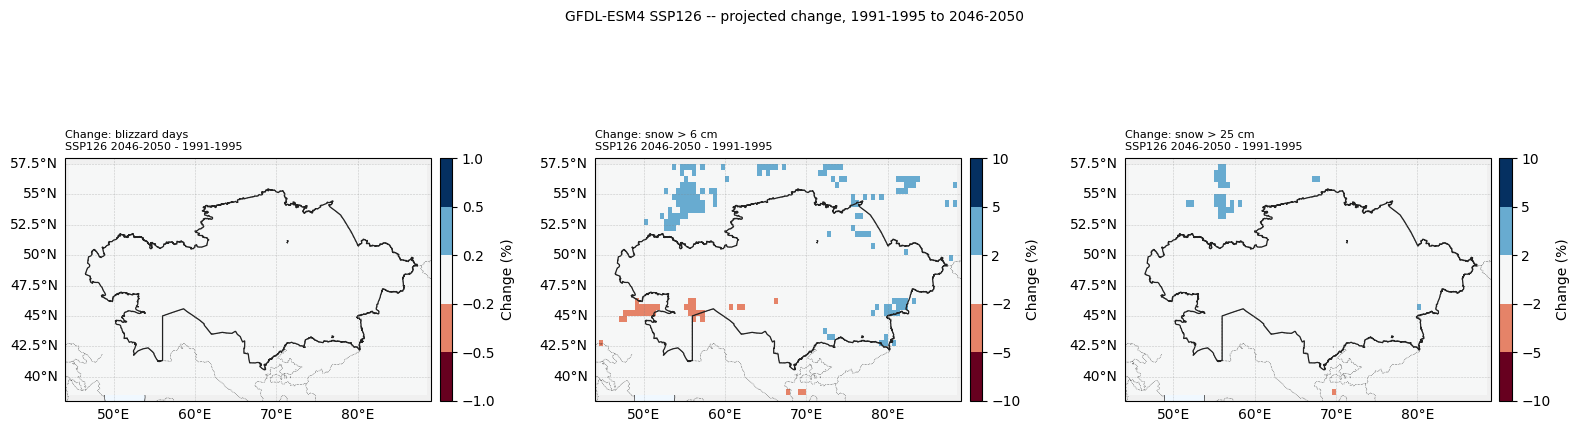

Saved: fig04_projected_change_ssp126.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (da, lvl, title) in zip(axes, [
    (chg_blizzard,
     [-1, -0.5, -0.2, 0.2, 0.5, 1],
     f'Change: blizzard days\n{ssp_primary.upper()} {FL} - {HL}'),
    (chg_snow6,
     [-10, -5, -2, 2, 5, 10],
     f'Change: snow > 6 cm\n{ssp_primary.upper()} {FL} - {HL}'),
    (chg_snow25,
     [-10, -5, -2, 2, 5, 10],
     f'Change: snow > 25 cm\n{ssp_primary.upper()} {FL} - {HL}'),
]):
    p = _pcm(ax, da, lvl, 'RdBu', lat='lat', lon='lon')
    _kz_map(ax, kz_national)
    ax.set_title(title, fontsize=8, loc='left')
    _cbar(fig, p, ax, label='Change (%)')

fig.suptitle(
    f'{gcm_model} {ssp_primary.upper()} -- projected change, {HL} to {FL}',
    fontsize=10, y=1.01)
plt.tight_layout()
save_fig(fig, 'fig04_projected_change_ssp126.png')

## Figure 5 -- Scenario comparison: blizzard change SSP1-2.6 vs SSP3-7.0

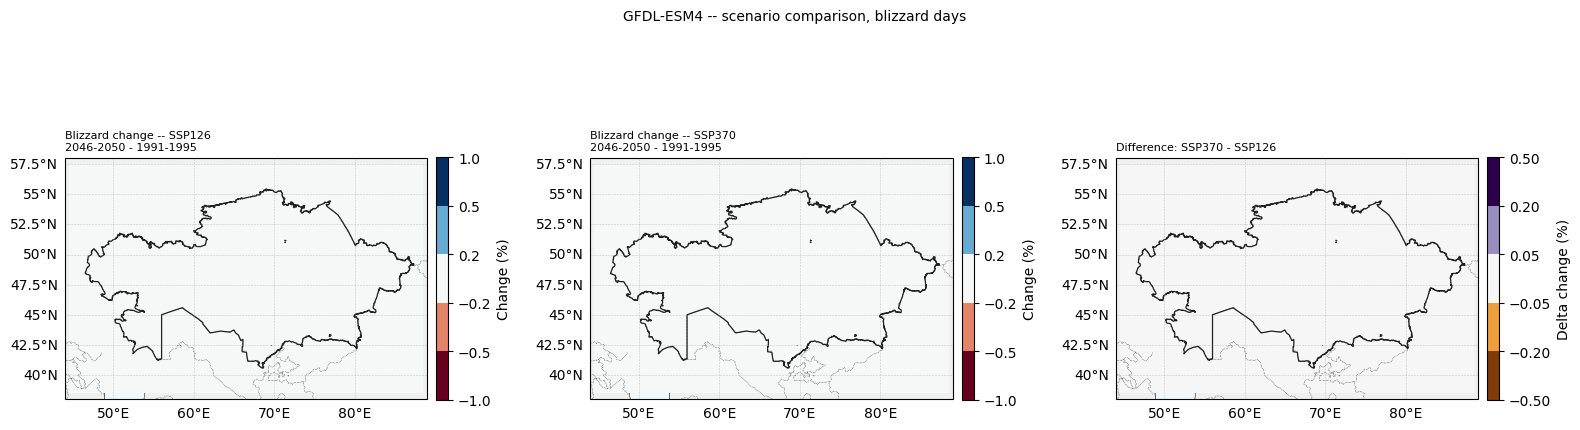

Saved: fig05_scenario_comparison_blizzard.png


In [11]:
if ssp2_blizzard is None:
    print(f'Figure 5 skipped -- {ssp_secondary} outputs not cached.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    lvl = [-1, -0.5, -0.2, 0.2, 0.5, 1]
    for ax, (da, lbl) in zip(axes[:2], [
        (chg_blizzard,  ssp_primary.upper()),
        (chg2_blizzard, ssp_secondary.upper()),
    ]):
        p = _pcm(ax, da, lvl, 'RdBu', lat='lat', lon='lon')
        _kz_map(ax, kz_national)
        ax.set_title(f'Blizzard change -- {lbl}\n{FL} - {HL}', fontsize=8, loc='left')
        _cbar(fig, p, ax, label='Change (%)')

    diff = chg2_blizzard - chg_blizzard
    diff.name = 'blizzard_days'
    p = _pcm(axes[2], diff,
             [-0.5, -0.2, -0.05, 0.05, 0.2, 0.5], 'PuOr',
             lat='lat', lon='lon')
    _kz_map(axes[2], kz_national)
    axes[2].set_title(
        f'Difference: {ssp_secondary.upper()} - {ssp_primary.upper()}',
        fontsize=8, loc='left')
    _cbar(fig, p, axes[2], label='Delta change (%)')

    fig.suptitle(f'{gcm_model} -- scenario comparison, blizzard days', fontsize=10, y=1.01)
    plt.tight_layout()
    save_fig(fig, 'fig05_scenario_comparison_blizzard.png')

## Figure 6 -- Exceedance: fraction of KZ domain exceeding annual probability threshold

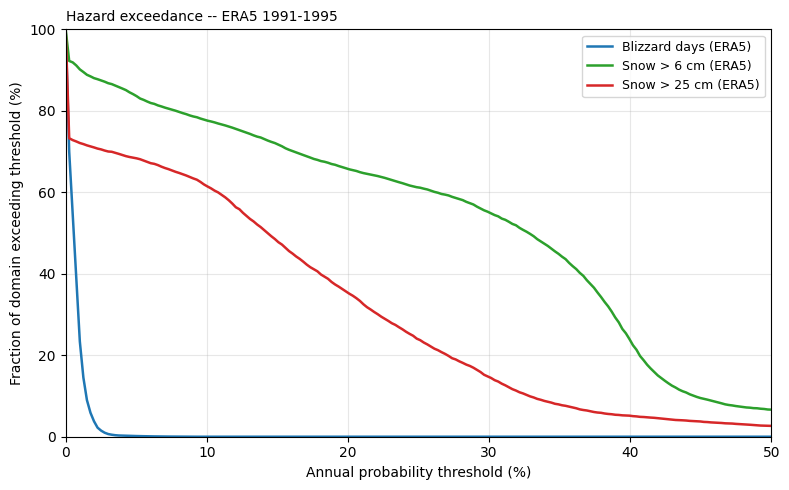

Saved: fig06_exceedance_curves.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
thresholds = np.linspace(0, 50, 200)

for da, label, color in [
    (era5_blizzard.blizzard_days, 'Blizzard days (ERA5)', '#1f77b4'),
    (era5_snow6.snow_days,         'Snow > 6 cm (ERA5)',   '#2ca02c'),
    (era5_snow25.snow_days,        'Snow > 25 cm (ERA5)',  '#d62728'),
]:
    vals = da.fillna(0).values.ravel()
    vals = vals[np.isfinite(vals)]
    fracs = np.array([(vals >= t).mean() * 100 for t in thresholds])
    ax.plot(thresholds, fracs, label=label, color=color, linewidth=1.8)

ax.set_xlabel('Annual probability threshold (%)', fontsize=10)
ax.set_ylabel('Fraction of domain exceeding threshold (%)', fontsize=10)
ax.set_title(f'Hazard exceedance -- ERA5 {HL}', fontsize=10, loc='left')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 50)
ax.set_ylim(0, 100)
plt.tight_layout()
save_fig(fig, 'fig06_exceedance_curves.png')

## Figure 7 -- Population exposure: blizzard probability in populated areas

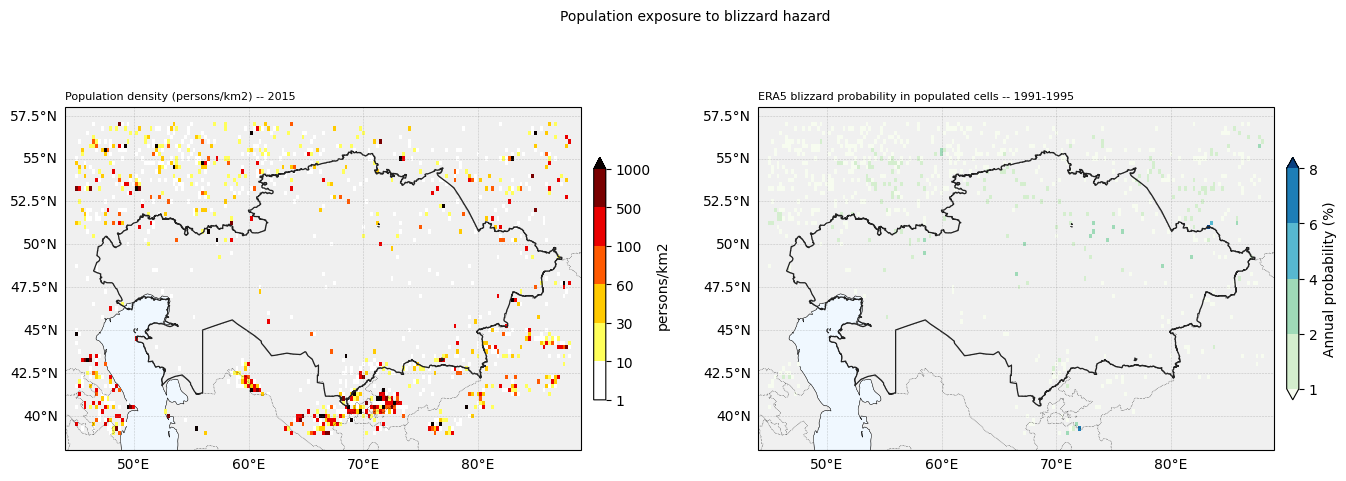

Saved: fig07_population_exposure_blizzard.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})

p0 = _pcm(axes[0], pop_era5.where(pop_era5 >= 1),
          [1, 10, 30, 60, 100, 500, 1000], 'hot_r')
_kz_map(axes[0], kz_national)
axes[0].set_title('Population density (persons/km2) -- 2015', fontsize=8, loc='left')
_cbar(fig, p0, axes[0], label='persons/km2')

blizzard_in_pop = era5_blizzard.blizzard_days.where(pop_era5.values >= 1)
p1 = _pcm(axes[1], blizzard_in_pop, [1, 2, 4, 6, 8], 'GnBu')
_kz_map(axes[1], kz_national)
axes[1].set_title(
    f'ERA5 blizzard probability in populated cells -- {HL}', fontsize=8, loc='left')
_cbar(fig, p1, axes[1])

fig.suptitle('Population exposure to blizzard hazard', fontsize=10, y=1.01)
plt.tight_layout()
save_fig(fig, 'fig07_population_exposure_blizzard.png')

## Figure 8 -- Population-weighted mean annual probability by indicator and data source

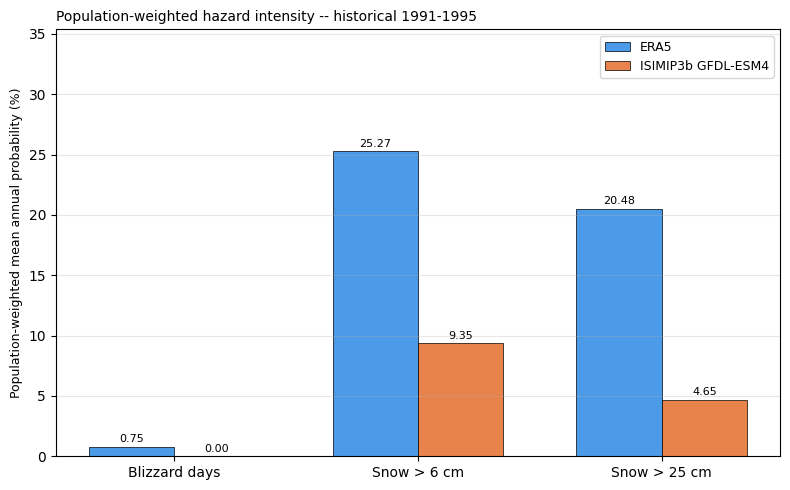

Saved: fig08_popweighted_hazard_intensity.png


In [14]:
def _pw_mean(hazard_vals, pop_vals):
    mask = np.isfinite(hazard_vals) & np.isfinite(pop_vals) & (pop_vals >= 1)
    return (np.nansum(hazard_vals[mask] * pop_vals[mask]) / np.nansum(pop_vals[mask])
            if mask.any() else 0.0)

labels     = ['Blizzard days', 'Snow > 6 cm', 'Snow > 25 cm']
era5_das   = [era5_blizzard.blizzard_days, era5_snow6.snow_days, era5_snow25.snow_days]
isimip_das = [hist_blizzard,               hist_snow6,            hist_snow25]

era5_means   = [_pw_mean(da.values.ravel(), pop_era5.values.ravel())   for da in era5_das]
isimip_means = [_pw_mean(da.values.ravel(), pop_isimip.values.ravel()) for da in isimip_das]

x     = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, era5_means,   width, label='ERA5',
            color='#4c9be8', edgecolor='k', linewidth=0.5)
b2 = ax.bar(x + width/2, isimip_means, width, label=f'ISIMIP3b {gcm_model}',
            color='#e8834c', edgecolor='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Population-weighted mean annual probability (%)', fontsize=9)
ax.set_title(f'Population-weighted hazard intensity -- historical {HL}', fontsize=10, loc='left')
ax.legend(fontsize=9)
ax.bar_label(b1, fmt='%.2f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.2f', fontsize=8, padding=2)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(max(era5_means), max(isimip_means), 0.01) * 1.4)
plt.tight_layout()
save_fig(fig, 'fig08_popweighted_hazard_intensity.png')

## Figure 9 -- Projected change vs historical baseline per grid cell (blizzard days)

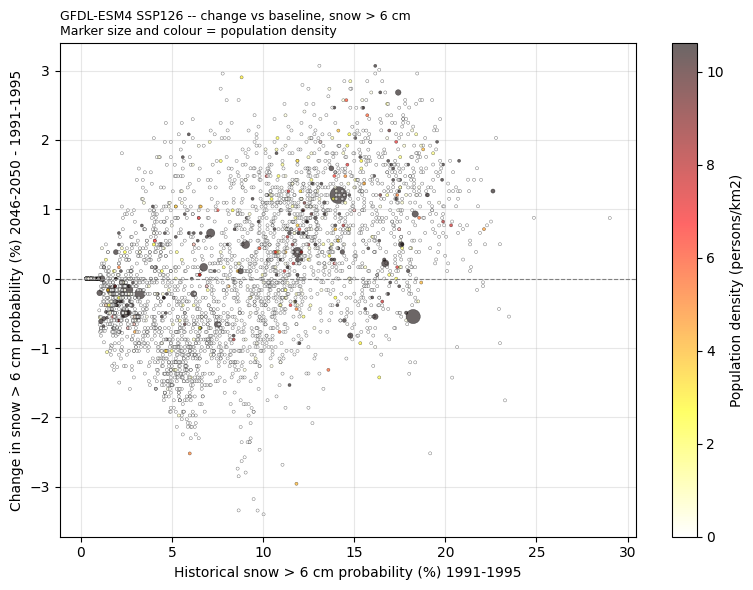

Saved: fig09_change_vs_baseline_scatter.png


In [19]:
h_flat = hist_snow6.values.ravel()
c_flat = chg_snow6.values.ravel()
p_flat = pop_isimip.values.ravel()

valid  = np.isfinite(h_flat) & np.isfinite(c_flat) & np.isfinite(p_flat)
h_v, c_v, p_v = h_flat[valid], c_flat[valid], p_flat[valid]

s   = np.clip(p_v / (p_v.max() + 1e-9) * 150, 5, 150)
p95 = np.percentile(p_v, 95) if p_v.size > 0 else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(h_v, c_v, c=p_v, s=s, cmap='hot_r',
                alpha=0.6, linewidths=0.3, edgecolors='k',
                vmin=0, vmax=max(p95, 1.0))
plt.colorbar(sc, ax=ax, label='Population density (persons/km2)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'Historical snow > 6 cm probability (%) {HL}', fontsize=10)
ax.set_ylabel(f'Change in snow > 6 cm probability (%) {FL} - {HL}', fontsize=10)
ax.set_title(
    f'{gcm_model} {ssp_primary.upper()} -- change vs baseline, snow > 6 cm\n'
    f'Marker size and colour = population density',
    fontsize=9, loc='left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig09_change_vs_baseline_scatter.png')

## Figure 10 -- Summary panel

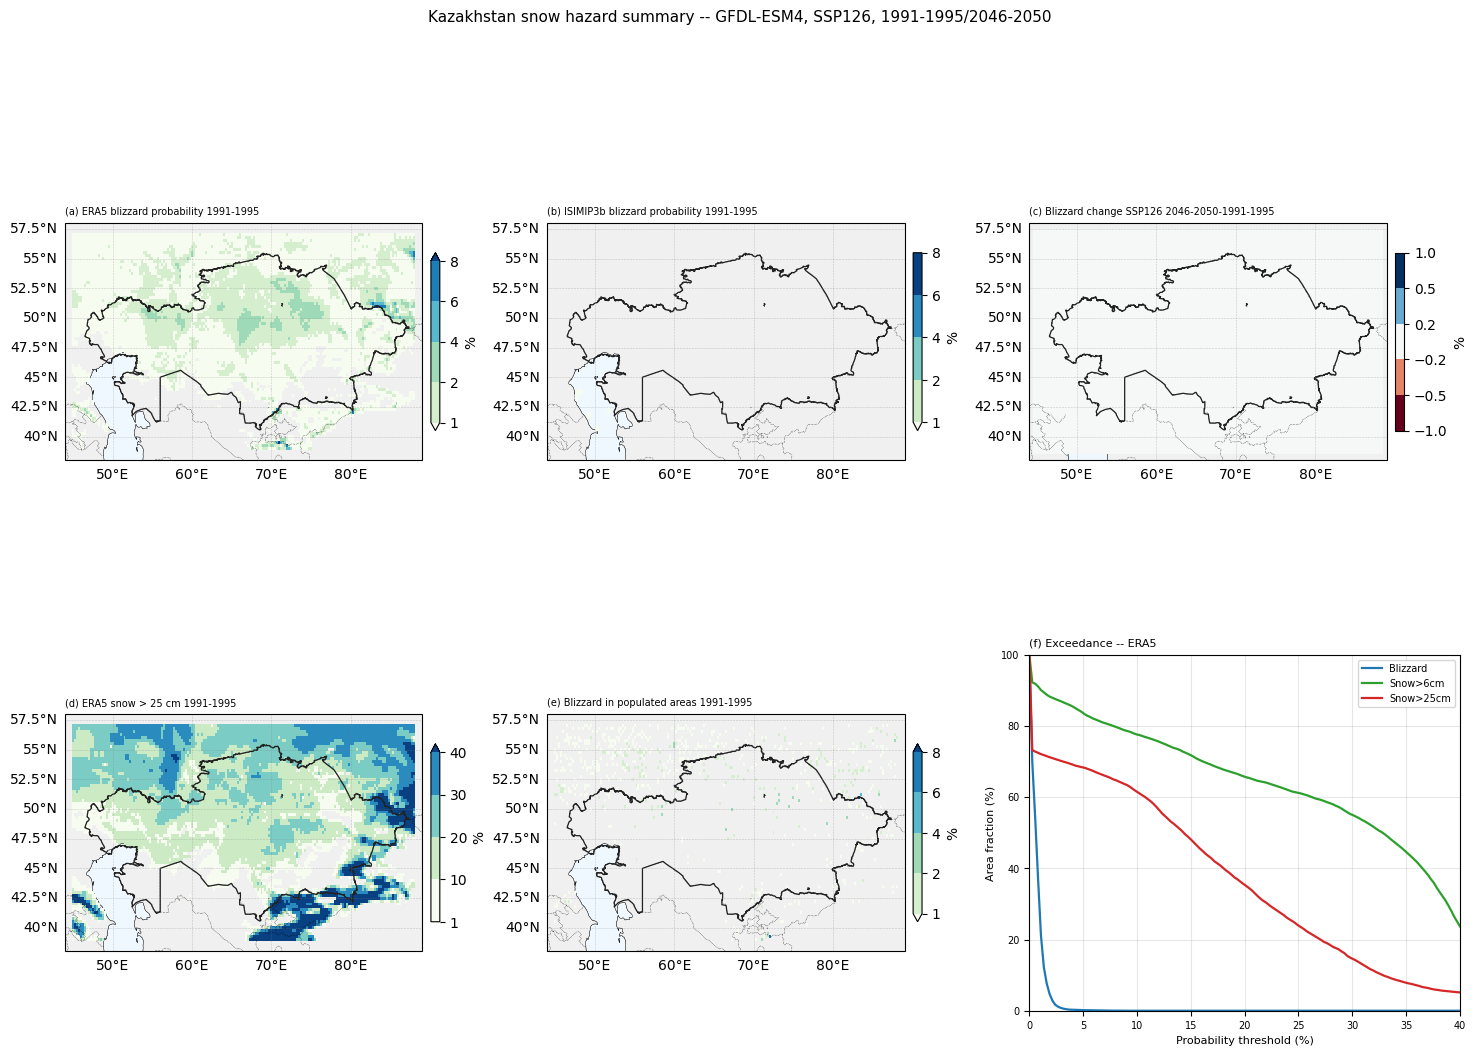

Saved: fig10_summary_panel.png


In [16]:
fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.12)

map_axes = [fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
            for r, c in [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]]
line_ax  = fig.add_subplot(gs[1, 2])

panel_data = [
    (era5_blizzard.blizzard_days,
     [1, 2, 4, 6, 8], 'GnBu',
     f'(a) ERA5 blizzard probability {HL}', 'latitude', 'longitude'),
    (hist_blizzard,
     [1, 2, 4, 6, 8], 'GnBu',
     f'(b) ISIMIP3b blizzard probability {HL}', 'lat', 'lon'),
    (chg_blizzard,
     [-1, -0.5, -0.2, 0.2, 0.5, 1], 'RdBu',
     f'(c) Blizzard change {ssp_primary.upper()} {FL}-{HL}', 'lat', 'lon'),
    (era5_snow25.snow_days.where(era5_snow25.snow_days >= 1),
     [1, 10, 20, 30, 40], 'GnBu',
     f'(d) ERA5 snow > 25 cm {HL}', 'latitude', 'longitude'),
    (era5_blizzard.blizzard_days.where(pop_era5.values >= 1),
     [1, 2, 4, 6, 8], 'GnBu',
     f'(e) Blizzard in populated areas {HL}', 'latitude', 'longitude'),
]
for ax, (da, lvl, cmap, title, lat_d, lon_d) in zip(map_axes, panel_data):
    p = _pcm(ax, da, lvl, cmap, lat=lat_d, lon=lon_d)
    _kz_map(ax, kz_national)
    ax.set_title(title, fontsize=7, loc='left')
    fig.colorbar(p, ax=ax, shrink=0.50, pad=0.02, label='%')

# Panel (f) -- exceedance curves
thresholds = np.linspace(0, 40, 150)
for da, label, color in [
    (era5_blizzard.blizzard_days, 'Blizzard',  '#1f77b4'),
    (era5_snow6.snow_days,         'Snow>6cm',  '#2ca02c'),
    (era5_snow25.snow_days,        'Snow>25cm', '#d62728'),
]:
    vals = da.fillna(0).values.ravel()
    vals = vals[np.isfinite(vals)]
    line_ax.plot(thresholds,
                 [((vals >= t).mean() * 100) for t in thresholds],
                 label=label, linewidth=1.6, color=color)
line_ax.set_xlabel('Probability threshold (%)', fontsize=8)
line_ax.set_ylabel('Area fraction (%)', fontsize=8)
line_ax.set_title('(f) Exceedance -- ERA5', fontsize=8, loc='left')
line_ax.legend(fontsize=7)
line_ax.grid(True, alpha=0.3)
line_ax.set_xlim(0, 40)
line_ax.set_ylim(0, 100)
line_ax.tick_params(labelsize=7)

fig.suptitle(
    f'Kazakhstan snow hazard summary -- {gcm_model}, {ssp_primary.upper()}, {HL}/{FL}',
    fontsize=11, y=1.02)
save_fig(fig, 'fig10_summary_panel.png')